# Enzyme Kinetics: Exercise 1

This notebook models an enzymatic reaction based on the Michaelis-Menten kinetics. 
First, let's import the necessary scientific Python libraries.

In [2]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set plotting styles for readability
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## Part a) Mass Balance for the System

The elementary reactions are:
$E + S \rightleftharpoons_{k_b}^{k_f} ES \xrightarrow{k_{cat}} E + P$

Assuming a constant volume reactor, the mass balances (concentration balances) for each species are:
* **Substrate ($S$):** $\frac{d[S]}{dt} = -k_f[E][S] + k_b[ES]$
* **Enzyme ($E$):** $\frac{d[E]}{dt} = -k_f[E][S] + (k_b + k_{cat})[ES]$
* **Enzyme-Substrate Complex ($ES$):** $\frac{d[ES]}{dt} = k_f[E][S] - (k_b + k_{cat})[ES]$
* **Product ($P$):** $\frac{d[P]}{dt} = k_{cat}[ES]$

## Part b) Numerical Solution of the Full ODE System

We will solve the ODE system for the interval $t \in [0, 5]$ s using the given parameters.
Because $k_f$ is very large ($10^4$) compared to the other parameters, this system is considered **stiff**. We will use the `Radau` or `BDF` method in `scipy.integrate.solve_ivp` to handle it accurately.

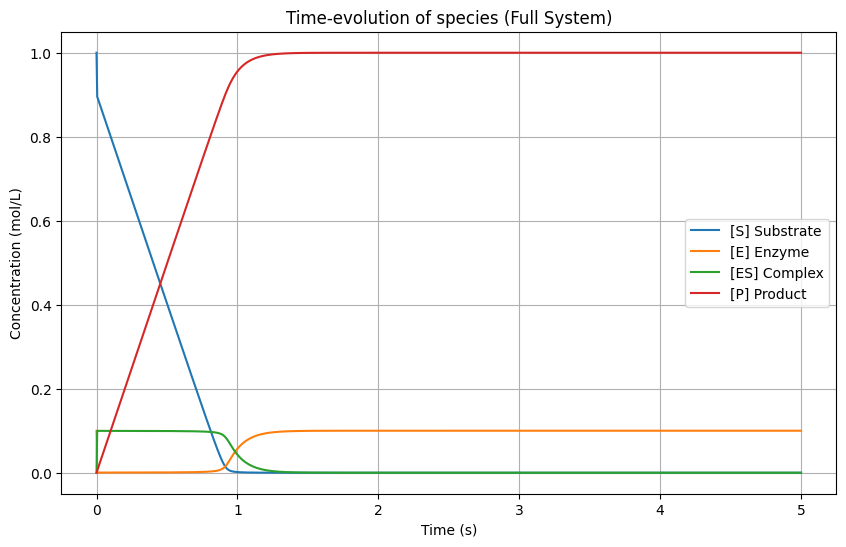

In [ ]:
# Parameters
k_f = 10**4   # L / (mol s)
k_b = 20      # s^-1
k_cat = 10    # s^-1

# Initial concentrations
S0 = 1.0
E0 = 0.1
ES0 = 0.0
P0 = 0.0
y0 = [S0, E0, ES0, P0]

def full_system(t, y):
    S, E, ES, P = y
    dS_dt = -k_f * E * S + k_b * ES
    dE_dt = -k_f * E * S + (k_b + k_cat) * ES
    dES_dt = k_f * E * S - (k_b + k_cat) * ES
    dP_dt = k_cat * ES
    return [dS_dt, dE_dt, dES_dt, dP_dt]

# Solve the ODE
t_span = (0, 5)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
sol_full = solve_ivp(full_system, t_span, y0, t_eval=t_eval, method='BDF')

# Plotting
plt.figure()
plt.plot(sol_full.t, sol_full.y[0], label='[S] Substrate')
plt.plot(sol_full.t, sol_full.y[1], label='[E] Enzyme')
plt.plot(sol_full.t, sol_full.y[2], label='[ES] Complex')
plt.plot(sol_full.t, sol_full.y[3], label='[P] Product')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Time-evolution of species (Full System)')
plt.legend()
plt.show()

## Part c) Quasi-Steady State Approximation (QSSA) Expression

Under QSSA, we assume the concentration of the intermediate complex $ES$ changes very slowly relative to the substrate and product, meaning $\frac{d[ES]}{dt} \approx 0$.

$k_f[E][S] - (k_b + k_{cat})[ES] = 0$

We also use the enzyme mass conservation: $[E]_0 = [E] + [ES]$, which gives $[E] = [E]_0 - [ES]$.
Substituting this into our equation:

$k_f([E]_0 - [ES])[S] - (k_b + k_{cat})[ES] = 0$
$k_f[E]_0[S] = k_f[ES][S] + (k_b + k_{cat})[ES]$
$k_f[E]_0[S] = [ES] (k_f[S] + k_b + k_{cat})$

Solving for $[ES]$:
$$[ES] = \frac{k_f[E]_0[S]}{k_f[S] + k_b + k_{cat}} = \frac{[E]_0[S]}{[S] + \frac{k_b + k_{cat}}{k_f}}$$

## Part d) Rewriting Mass Balance and Solving with QSSA

Let $K_M = \frac{k_b + k_{cat}}{k_f}$. Our expression for $[ES]$ becomes:
$$[ES] = \frac{[E]_0[S]}{[S] + K_M}$$

The product formation rate is:
$$\frac{d[P]}{dt} = k_{cat}[ES] = \frac{k_{cat}[E]_0[S]}{[S] + K_M}$$

Since the substrate is consumed to form the product, the simplified mass balance for the substrate under QSSA is:
$$\frac{d[S]}{dt} = -\frac{d[P]}{dt} = -\frac{k_{cat}[E]_0[S]}{[S] + K_M}$$

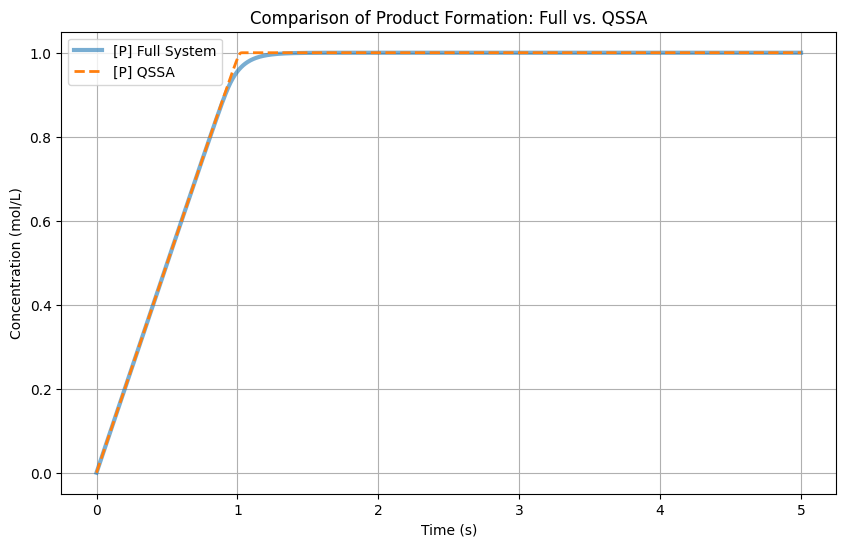

In [5]:
# QSSA Parameters
K_M = (k_b + k_cat) / k_f

def qssa_system(t, y):
    S, P = y
    dP_dt = (k_cat * E0 * S) / (S + K_M)
    dS_dt = -dP_dt
    return [dS_dt, dP_dt]

# Solve the QSSA ODE
y0_qssa = [S0, P0]
sol_qssa = solve_ivp(qssa_system, t_span, y0_qssa, t_eval=t_eval, method='BDF')

# Comparison Plot
plt.figure()
plt.plot(sol_full.t, sol_full.y[3], label='[P] Full System', linewidth=3, alpha=0.6)
plt.plot(sol_qssa.t, sol_qssa.y[1], '--', label='[P] QSSA', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Comparison of Product Formation: Full vs. QSSA')
plt.legend()
plt.show()

## Part e & f) Initial Rate vs Parameters and Scaled Sensitivity

The initial reaction rate $v$ at $t=0$ is given by:
$$v = \frac{k_{cat}[E]_0[S]_0}{[S]_0 + \frac{k_b + k_{cat}}{k_f}}$$

Scaled sensitivity of $v$ with respect to a parameter $p$ is defined as $S_p = \frac{\partial \ln v}{\partial \ln p}$, which represents the slope of a log-log plot.

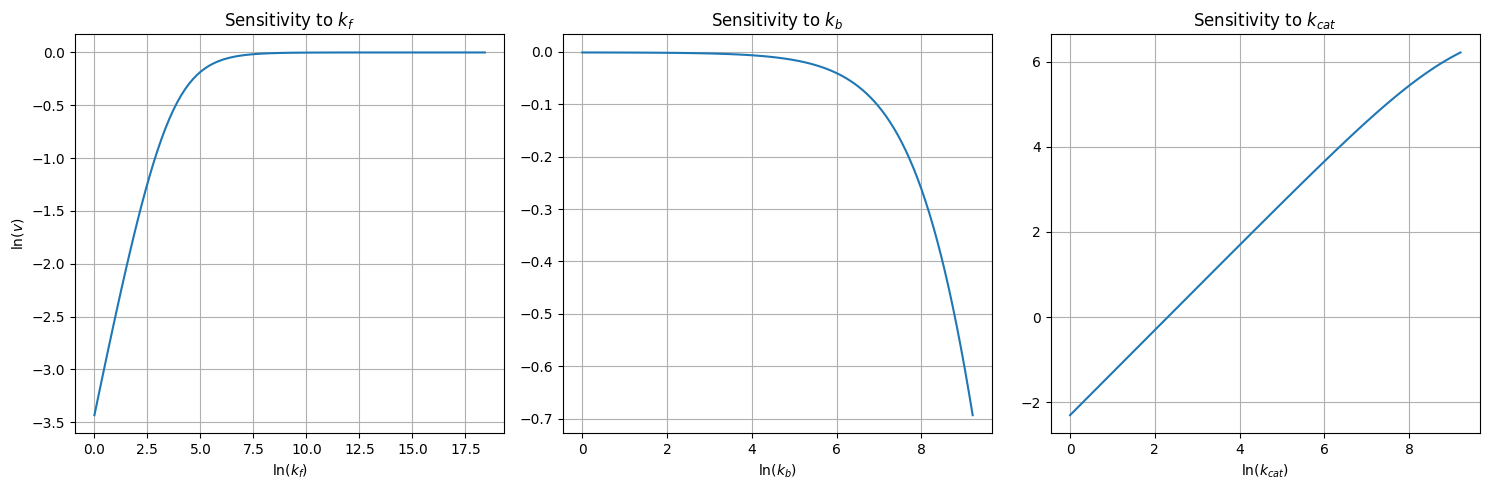

In [7]:
# Determine v(t=0) as a function of parameters
def calc_v0(kf, kb, kcat, E_init=0.1, S_init=1.0):
    KM = (kb + kcat) / kf
    return (kcat * E_init * S_init) / (S_init + KM)

# Ranges for parameters
kf_range = np.logspace(0, 8, 100)
kb_range = np.logspace(0, 4, 100)
kcat_range = np.logspace(0, 4, 100)

# Calculate v0 over the ranges (varying one, keeping others at default)
v0_kf = calc_v0(kf_range, k_b, k_cat)
v0_kb = calc_v0(k_f, kb_range, k_cat)
v0_kcat = calc_v0(k_f, k_b, kcat_range)

# Plotting Log-Log Scaled Sensitivities
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(np.log(kf_range), np.log(v0_kf))
axs[0].set_xlabel('$\\ln(k_f)$')
axs[0].set_ylabel('$\\ln(v)$')
axs[0].set_title('Sensitivity to $k_f$')

axs[1].plot(np.log(kb_range), np.log(v0_kb))
axs[1].set_xlabel('$\\ln(k_b)$')
axs[1].set_title('Sensitivity to $k_b$')

axs[2].plot(np.log(kcat_range), np.log(v0_kcat))
axs[2].set_xlabel('$\\ln(k_{cat})$')
axs[2].set_title('Sensitivity to $k_{cat}$')

plt.tight_layout()
plt.show()

# Conclusion on f: 
# The slope of the ln(v) vs ln(parameter) plot gives the scaled sensitivity. 
# The steepest slope (positive or negative) near our operating point indicates the most important parameter.

## Part g) Mass Balance for the Non-Specific Enzyme

The new mechanism produces two products, $P$ and $P'$:
$E + S \rightleftharpoons_{k_b}^{k_f} ES \xrightarrow{k_{cat1}} E + P$
$ES \xrightarrow{k_{cat2}} E + P'$

The mass balances **without** QSSA are:
* $\frac{d[S]}{dt} = -k_f[E][S] + k_b[ES]$
* $\frac{d[E]}{dt} = -k_f[E][S] + (k_b + k_{cat1} + k_{cat2})[ES]$
* $\frac{d[ES]}{dt} = k_f[E][S] - (k_b + k_{cat1} + k_{cat2})[ES]$
* $\frac{d[P]}{dt} = k_{cat1}[ES]$
* $\frac{d[P']}{dt} = k_{cat2}[ES]$

## Part h) Solving the Extended ODE System

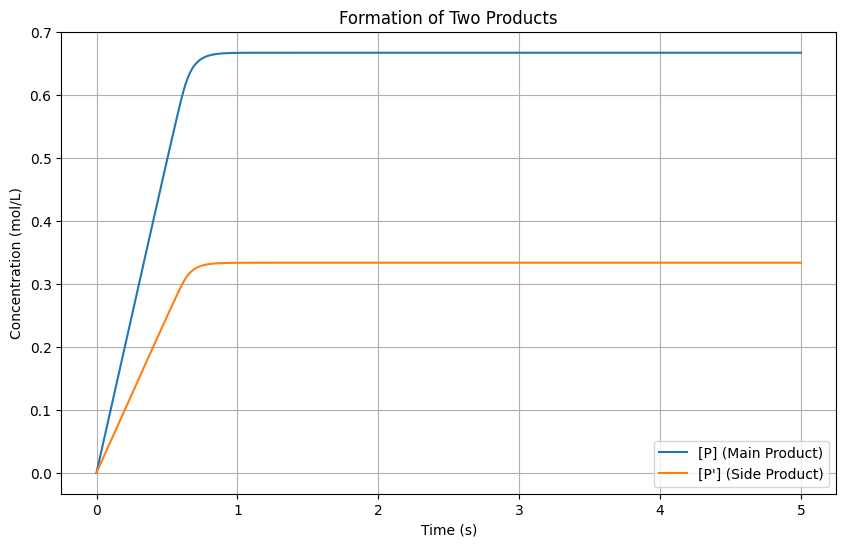

In [8]:
# New parameter
k_cat1 = 10
k_cat2 = 5

y0_new = [1.0, 0.1, 0.0, 0.0, 0.0] # S, E, ES, P, P'

def new_system(t, y):
    S, E, ES, P, P_prime = y
    dS_dt = -k_f * E * S + k_b * ES
    dE_dt = -k_f * E * S + (k_b + k_cat1 + k_cat2) * ES
    dES_dt = k_f * E * S - (k_b + k_cat1 + k_cat2) * ES
    dP_dt = k_cat1 * ES
    dP_prime_dt = k_cat2 * ES
    return [dS_dt, dE_dt, dES_dt, dP_dt, dP_prime_dt]

sol_new = solve_ivp(new_system, t_span, y0_new, t_eval=t_eval, method='BDF')

plt.figure()
plt.plot(sol_new.t, sol_new.y[3], label='[P] (Main Product)')
plt.plot(sol_new.t, sol_new.y[4], label="[P'] (Side Product)")
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Formation of Two Products')
plt.legend()
plt.show()

## Part i) Increasing Selectivity

Selectivity for the main product $P$ over the side product $P'$ is defined as the ratio of their formation rates:

$$\text{Selectivity} = \frac{d[P]/dt}{d[P']/dt} = \frac{k_{cat1}[ES]}{k_{cat2}[ES]} = \frac{k_{cat1}}{k_{cat2}}$$

To increase the selectivity towards product $P$, you would need to either:
1.  **Increase $k_{cat1}$** (the catalytic rate constant for $P$)
2.  **Decrease $k_{cat2}$** (the catalytic rate constant for $P'$)

Changes to $k_f$, $k_b$, or $[E]_0$ affect the overall reaction speed but do not change the fundamental ratio of $P$ to $P'$ being produced.